# loss_01 — LGD Exploration (clean rebuild)

**Goal:** Explore LGD on LendingClub 2007–2018 charged-off loans **without preconceptions**.


## 1.1 Imports & Paths

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# TODO: 改成你本地的路径
RAW_DIR       = Path("/Users/dongshuxin/Desktop/Projects/data")
ACCEPTED_FILE = RAW_DIR / "accepted_2007_to_2018Q4.csv.gz"

OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input :", ACCEPTED_FILE, "exists =", ACCEPTED_FILE.exists())
print("Output:", OUT_DIR.resolve())

Input : /Users/dongshuxin/Desktop/Projects/data/accepted_2007_to_2018Q4.csv.gz exists = True
Output: /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed


## 1.2 Load minimal columns

We only pull what's needed for LGD work. Keeping the loaded frame small lets us iterate fast.

In [2]:
USECOLS = [
    "id", "loan_status", "issue_d", "term",
    "grade", "sub_grade",
    "loan_amnt", "funded_amnt",
    "total_rec_prncp",        # principal already repaid before default
    "recoveries",             # post charge-off gross recovery
    "collection_recovery_fee",# fees taken out of recovery
    "out_prncp",              # outstanding principal (for not-yet-resolved loans)
]

df = pd.read_csv(ACCEPTED_FILE, usecols=USECOLS, low_memory=False)
print("Rows loaded:", f"{len(df):,}")
df.head()

Rows loaded: 2,260,701


,id,loan_amnt,funded_amnt,term,grade,sub_grade,issue_d,loan_status,out_prncp,total_rec_prncp,recoveries,collection_recovery_fee
0,68407277,3600.0,3600.0,36 months,C,C4,Dec-2015,Fully Paid,0.00,3600.00,0.0,0.0
1,68355089,24700.0,24700.0,36 months,C,C1,Dec-2015,Fully Paid,0.00,24700.00,0.0,0.0
2,68341763,20000.0,20000.0,60 months,B,B4,Dec-2015,Fully Paid,0.00,20000.00,0.0,0.0
3,66310712,35000.0,35000.0,60 months,C,C5,Dec-2015,Current,15897.65,19102.35,0.0,0.0
4,68476807,10400.0,10400.0,60 months,F,F1,Dec-2015,Fully Paid,0.00,10400.00,0.0,0.0


In [3]:
# Quick sanity: missingness on the fields we care about
df[USECOLS].isna().mean().sort_values(ascending=False).round(4)

loan_status                0.0
issue_d                    0.0
term                       0.0
grade                      0.0
sub_grade                  0.0
loan_amnt                  0.0
funded_amnt                0.0
total_rec_prncp            0.0
recoveries                 0.0
collection_recovery_fee    0.0
out_prncp                  0.0
id                         0.0
dtype: float64

In [4]:
# Parse vintage and term
df["issue_dt"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["vintage_year"] = df["issue_dt"].dt.year
df["term_num"]    = df["term"].astype(str).str.extract(r"(\d+)").astype(float)
df["loan_status"].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

## 1.3 Define the default population

For **LGD**, we **exclude** late-but-not-yet-charged-off statuses because their recovery is incomplete.


In [5]:
DEFAULT_STATUSES = ["Charged Off", "Default"]

default = df[df["loan_status"].isin(DEFAULT_STATUSES)].copy()
print(f"Default population: {len(default):,} loans "
      f"({len(default)/len(df):.2%} of all originated)")
default["loan_status"].value_counts()

Default population: 268,599 loans (11.88% of all originated)


loan_status
Charged Off    268559
Default            40
Name: count, dtype: int64

## 1.4 Inspect raw recovery / repayment fields (no math yet)

Before defining LGD, we look at the building blocks raw — `recoveries`, `collection_recovery_fee`, `total_rec_prncp`, `funded_amnt`, `out_prncp` — to understand what we're working with.

In [6]:
raw_fields = ["funded_amnt", "total_rec_prncp",
              "recoveries", "collection_recovery_fee",
              "out_prncp"]
default[raw_fields].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).round(2)

,funded_amnt,total_rec_prncp,recoveries,collection_recovery_fee,out_prncp
count,268599.00,268599.00,268599.00,268599.00,268599.00
mean,15556.88,4387.94,1209.28,201.50,1.43
std,8811.22,4122.51,1847.22,329.30,153.05
min,900.00,0.00,0.00,0.00,0.00
10%,5000.00,691.37,0.00,0.00,0.00
25%,9000.00,1520.75,0.00,0.00,0.00
50%,14325.00,3157.35,592.00,80.03,0.00
75%,20400.00,5900.87,1723.59,283.52,0.00
90%,29900.00,9685.23,3172.77,545.63,0.00
99%,35000.00,19550.37,8455.00,1500.14,0.00


In [7]:
# How many defaults have recovery == 0?
zero_recov = (default["recoveries"].fillna(0) <= 0).mean()
any_recov  = 1 - zero_recov
print(f"Defaults with zero recovery : {zero_recov:.2%}")
print(f"Defaults with some recovery : {any_recov:.2%}")

# Net recovery (recoveries minus collection fees)
default["net_recov"] = (default["recoveries"].fillna(0)
                       - default["collection_recovery_fee"].fillna(0))
default["net_recov"].describe(percentiles=[0.5, 0.75, 0.9, 0.99]).round(2)

Defaults with zero recovery : 31.24%
Defaults with some recovery : 68.76%


count    268599.00
mean       1007.78
std        1533.23
min           0.00
50%         493.62
75%        1437.94
90%        2654.56
99%        6946.22
max       39397.81
Name: net_recov, dtype: float64

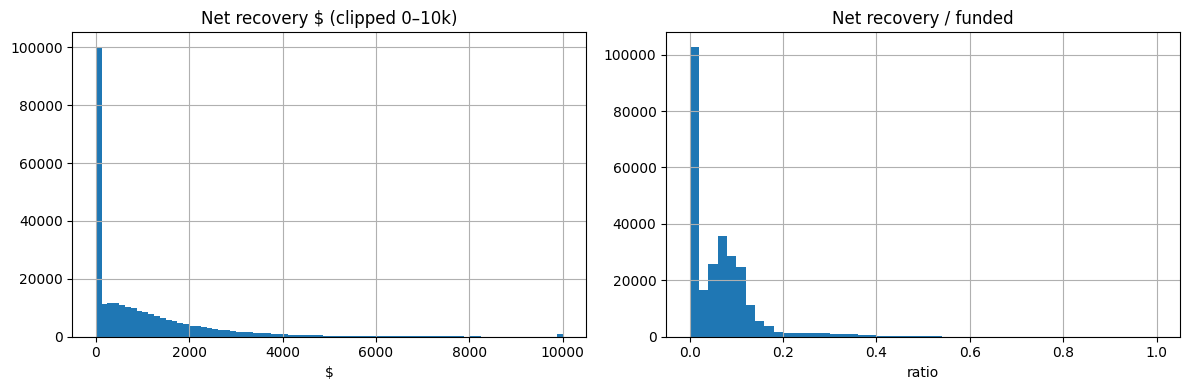

In [8]:
# Visual: distribution of net recovery (clip extreme tail for readability)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
default["net_recov"].clip(lower=0, upper=10000).hist(bins=80, ax=ax[0])
ax[0].set_title("Net recovery $ (clipped 0–10k)")
ax[0].set_xlabel("$")

(default["net_recov"] / default["funded_amnt"]).clip(0, 1).hist(bins=50, ax=ax[1])
ax[1].set_title("Net recovery / funded")
ax[1].set_xlabel("ratio")
plt.tight_layout(); plt.show()

## 1.5 Compute candidate LGD definitions — side by side



In [9]:
d = default.copy()

# Common pieces
d["net_recov"]  = d["recoveries"].fillna(0) - d["collection_recovery_fee"].fillna(0)
d["prncp_paid"] = d["total_rec_prncp"].fillna(0)
d["funded"]     = d["funded_amnt"].fillna(d["loan_amnt"])

# A) Funded convention
d["lgd_funded"] = 1 - (d["prncp_paid"] + d["net_recov"]) / d["funded"]

# B) Outstanding convention
d["ead_at_default"]  = (d["funded"] - d["prncp_paid"]).clip(lower=1.0)  # avoid /0
d["lgd_outstanding"] = 1 - (d["net_recov"] / d["ead_at_default"])

# Clip to [0, 1] — values outside come from rounding / edge cases
d["lgd_funded"]      = d["lgd_funded"].clip(0, 1)
d["lgd_outstanding"] = d["lgd_outstanding"].clip(0, 1)

print("Funded LGD     summary:")
print(d["lgd_funded"].describe(percentiles=[0.1, 0.5, 0.9]).round(4), "\n")
print("Outstanding LGD summary:")
print(d["lgd_outstanding"].describe(percentiles=[0.1, 0.5, 0.9]).round(4))

Funded LGD     summary:
count    268599.0000
mean          0.6344
std           0.2149
min           0.0000
10%           0.3166
50%           0.6765
90%           0.8783
max           1.0000
Name: lgd_funded, dtype: float64 

Outstanding LGD summary:
count    268599.0000
mean          0.9086
std           0.1109
min           0.0000
10%           0.8196
50%           0.9154
90%           1.0000
max           1.0000
Name: lgd_outstanding, dtype: float64


## 1.6 LGD distribution — both conventions

Side-by-side histograms make the difference visible.

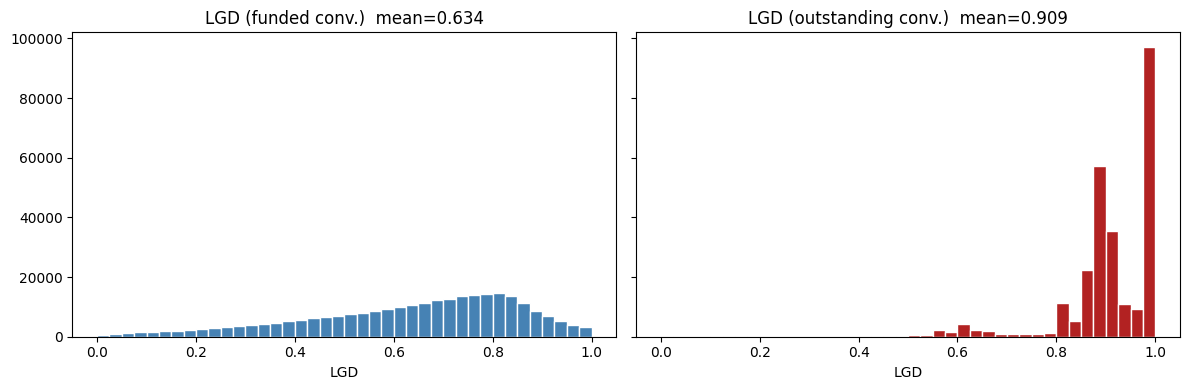

,funded,outstanding
mean,0.6344,0.9086
median,0.6765,0.9154
std,0.2149,0.1109


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax[0].hist(d["lgd_funded"], bins=40, color="steelblue", edgecolor="white")
ax[0].set_title(f"LGD (funded conv.)  mean={d['lgd_funded'].mean():.3f}")
ax[0].set_xlabel("LGD")

ax[1].hist(d["lgd_outstanding"], bins=40, color="firebrick", edgecolor="white")
ax[1].set_title(f"LGD (outstanding conv.)  mean={d['lgd_outstanding'].mean():.3f}")
ax[1].set_xlabel("LGD")

plt.tight_layout(); plt.show()

# Summary table
summary = pd.DataFrame({
    "funded":      d["lgd_funded"].agg(["mean", "median", "std"]),
    "outstanding": d["lgd_outstanding"].agg(["mean", "median", "std"]),
}).round(4)
summary

**What to look for in the plots above:**
- The funded-convention histogram tends to have more mass in the middle (because partial principal repayment dilutes the loss).
- The outstanding-convention histogram should be more right-skewed toward 1.0 — once a loan defaults, most of the remaining exposure is lost.

If outstanding LGD ≈ 0.94–0.97, that matches the published Basel-style LGD literature for unsecured consumer loans well.

## 1.7 Segmentation — grade / sub_grade / term

Question: does LGD vary meaningfully across credit grades or term?
If **yes** → use a segmented LGD lookup in EL.
If **no** → a single constant LGD is fine and simpler.

In [11]:
def lgd_by(col, lgd_col="lgd_outstanding"):
    g = (d.groupby(col)[lgd_col]
           .agg(["count", "mean", "median", "std"])
           .round(4))
    return g

print("=== By grade ===")
print(lgd_by("grade"))
print("\n=== By term ===")
print(lgd_by("term_num"))
print("\n=== By sub_grade (head) ===")
print(lgd_by("sub_grade").head(10))

=== By grade ===
       count    mean  median     std
grade                               
A      14206  0.9115  0.9435  0.1326
B      52576  0.9098  0.9174  0.1151
C      85657  0.9093  0.9150  0.1077
D      61067  0.9090  0.9144  0.1086
E      36041  0.9062  0.9135  0.1083
F      14492  0.9035  0.9118  0.1080
G       4560  0.9047  0.9104  0.1033

=== By term ===
           count    mean  median     std
term_num                                
36.0      163277  0.9070  0.9158  0.1156
60.0      105322  0.9111  0.9148  0.1031

=== By sub_grade (head) ===
           count    mean  median     std
sub_grade                               
A1          1409  0.9195  0.9998  0.1387
A2          1734  0.9097  0.9672  0.1392
A3          2094  0.9124  0.9470  0.1333
A4          3588  0.9113  0.9427  0.1302
A5          5381  0.9096  0.9377  0.1301
B1          7416  0.9115  0.9209  0.1196
B2          8410  0.9095  0.9184  0.1192
B3         10625  0.9098  0.9178  0.1137
B4         12337  0.9104  0.91

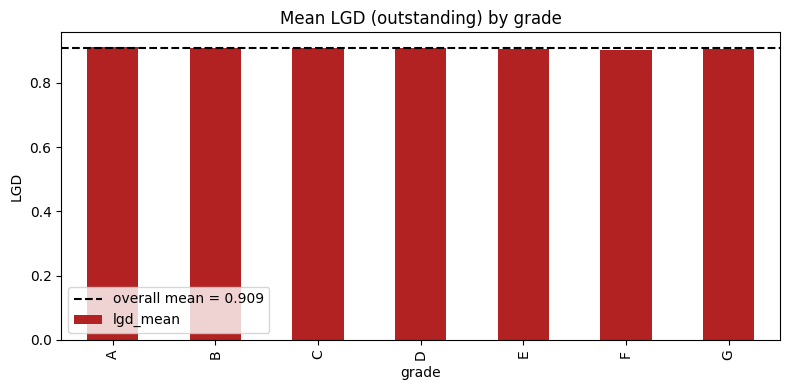

In [12]:
# Visual: LGD by grade
lgd_grade = lgd_by("grade")[["mean"]].rename(columns={"mean":"lgd_mean"})
lgd_grade.plot(kind="bar", figsize=(8, 4), color="firebrick", legend=False)
plt.title("Mean LGD (outstanding) by grade")
plt.ylabel("LGD")
plt.axhline(d["lgd_outstanding"].mean(), color="black", linestyle="--",
            label=f"overall mean = {d['lgd_outstanding'].mean():.3f}")
plt.legend(); plt.tight_layout(); plt.show()

## 1.8 Vintage stability

If LGD swings wildly across vintages, a single constant becomes risky. Check whether mean LGD is roughly stable over `vintage_year`.

              count    mean  median
vintage_year                       
2007.0           45  0.8886  0.9554
2008.0          247  0.9187  0.9842
2009.0          594  0.9212  0.9554
2010.0         1487  0.9224  0.9550
2011.0         3297  0.9143  0.9429
2012.0         8644  0.8968  0.9039
2013.0        21024  0.8855  0.8780
2014.0        41162  0.8912  0.9024
2015.0        75804  0.8999  0.9159
2016.0        68252  0.9134  0.9150
2017.0        39169  0.9351  0.9605
2018.0         8874  0.9717  1.0000


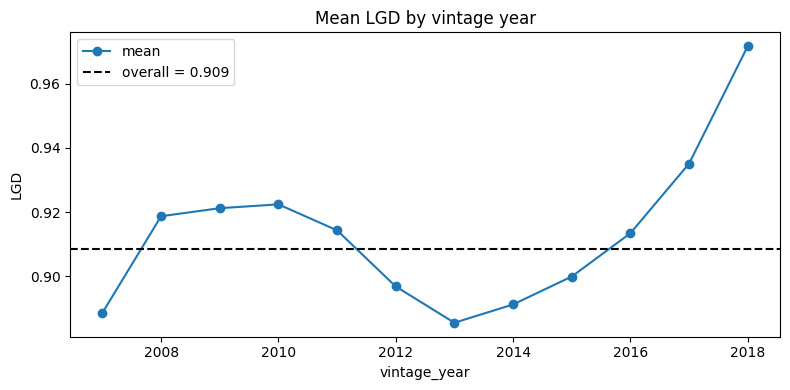

In [13]:
lgd_vint = (d.groupby("vintage_year")["lgd_outstanding"]
              .agg(["count", "mean", "median"])
              .round(4))
print(lgd_vint)

lgd_vint["mean"].plot(figsize=(8, 4), marker="o")
plt.axhline(d["lgd_outstanding"].mean(), color="black", linestyle="--",
            label=f"overall = {d['lgd_outstanding'].mean():.3f}")
plt.title("Mean LGD by vintage year")
plt.ylabel("LGD")
plt.legend(); plt.tight_layout(); plt.show()

## 1.81 Bias-Why does LGD spike in 2017-2018?

                  n  pct_zero_recov  mean_net_recov_dollars  mean_lgd
vintage_year                                                         
2007.0           45          0.0000                526.1809    0.8886
2008.0          247          0.0243                392.0043    0.9187
2009.0          594          0.0135                474.9506    0.9212
2010.0         1487          0.0054                483.5520    0.9224
2011.0         3297          0.0112                696.7060    0.9143
2012.0         8644          0.0227                928.5918    0.8968
2013.0        21024          0.0846               1156.7479    0.8855
2014.0        41162          0.2577               1132.5081    0.8912
2015.0        75804          0.2995               1068.9101    0.8999
2016.0        68252          0.3518                998.2796    0.9134
2017.0        39169          0.4566                895.7874    0.9351
2018.0         8874          0.7526                457.3250    0.9717


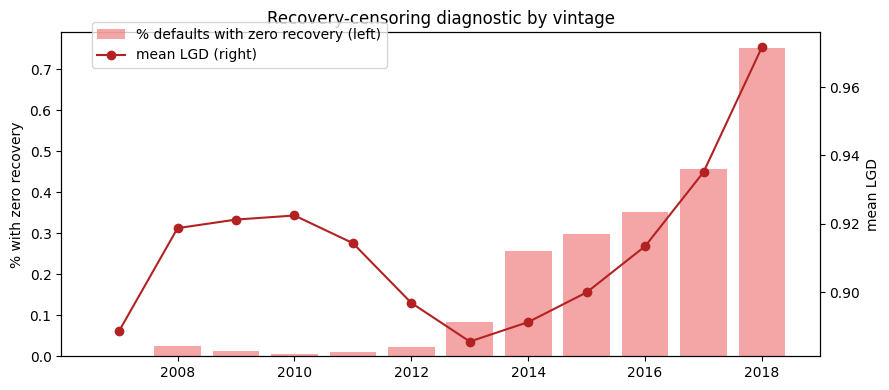

In [14]:
diag = (d.assign(zero_recov=(d["net_recov"] <= 0))
          .groupby("vintage_year")
          .agg(n=("id","count"),
               pct_zero_recov=("zero_recov","mean"),
               mean_net_recov_dollars=("net_recov","mean"),
               mean_lgd=("lgd_outstanding","mean"))
          .round(4))
print(diag)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(diag.index, diag["pct_zero_recov"], color="lightcoral", alpha=0.7,
        label="% defaults with zero recovery (left)")
ax1.set_ylabel("% with zero recovery")
ax2 = ax1.twinx()
ax2.plot(diag.index, diag["mean_lgd"], marker="o", color="firebrick",
         label="mean LGD (right)")
ax2.set_ylabel("mean LGD")
plt.title("Recovery-censoring diagnostic by vintage")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout(); plt.show()

We could see the share of defaults with recoveries == 0 climb sharply for 2017–2018 vintage which explains that the spike is caused by imcomplete recovery process, not by worse losses.

## 1.9 Decision: constant LGD on the **mature** window
 We drop:
   - 2007–2009: too few observations, financial-crisis distortions, different platform era.
   - 2017–2018: recovery process not yet complete (proven in §1.8-bis), would inflate LGD upward.


In [15]:
MATURE_MIN, MATURE_MAX = 2010, 2016
mature = d[(d["vintage_year"] >= MATURE_MIN) & (d["vintage_year"] <= MATURE_MAX)].copy()

lgd_const_full     = float(d["lgd_outstanding"].mean())          # all vintages
lgd_const_mature   = float(mature["lgd_outstanding"].mean())     # mature window
lgd_const_funded   = float(mature["lgd_funded"].mean())          # for reference

lgd_grade_table_mature = (mature.groupby("grade")["lgd_outstanding"]
                                 .mean().round(4).to_dict())
spread_mature = (max(lgd_grade_table_mature.values())
                 - min(lgd_grade_table_mature.values())) if lgd_grade_table_mature else 0.0
use_constant  = spread_mature < 0.03

decision = {
    "convention_recommended": "outstanding",
    "calibration_window":     [MATURE_MIN, MATURE_MAX],
    "lgd_const_outstanding_full_sample":   round(lgd_const_full,   4),
    "lgd_const_outstanding_mature":        round(lgd_const_mature, 4),  # <- THE ONE TO USE
    "lgd_const_funded_mature_for_ref":     round(lgd_const_funded, 4),
    "grade_spread_mature":                 round(spread_mature, 4),
    "use_constant":                        bool(use_constant),
    "lgd_by_grade_mature":                 lgd_grade_table_mature,
    "n_defaults_full":                     int(len(d)),
    "n_defaults_mature":                   int(len(mature)),
    "default_statuses":                    DEFAULT_STATUSES,
    "excluded_vintages_reason": {
        "2007-2009": "small n + financial-crisis regime + early-platform noise",
        "2017-2018": "recovery right-censoring (see 1.8-bis); LGD would be inflated"
    },
}
print(f"Full-sample LGD : {lgd_const_full:.4f}  (n={len(d):,})")
print(f"Mature-window LGD: {lgd_const_mature:.4f}  (n={len(mature):,})  <- USE THIS")
decision

Full-sample LGD : 0.9086  (n=268,599)
Mature-window LGD: 0.9013  (n=219,670)  <- USE THIS


{'convention_recommended': 'outstanding',
 'calibration_window': [2010, 2016],
 'lgd_const_outstanding_full_sample': 0.9086,
 'lgd_const_outstanding_mature': 0.9013,
 'lgd_const_funded_mature_for_ref': 0.6013,
 'grade_spread_mature': 0.0047,
 'use_constant': True,
 'lgd_by_grade_mature': {'A': 0.9014,
  'B': 0.902,
  'C': 0.9017,
  'D': 0.9013,
  'E': 0.901,
  'F': 0.8989,
  'G': 0.8973},
 'n_defaults_full': 268599,
 'n_defaults_mature': 219670,
 'default_statuses': ['Charged Off', 'Default'],
 'excluded_vintages_reason': {'2007-2009': 'small n + financial-crisis regime + early-platform noise',
  '2017-2018': 'recovery right-censoring (see 1.8-bis); LGD would be inflated'}}

We will use mean value of Mature-window LGD which is 0.9013 for the further research and analysis.

## 1.10 Save outputs for `loss_02`

Two artifacts:
- `lgd_decision.json` — the constants + decision flag (small, easy to import)
- `lgd_by_grade.csv` — the per-grade lookup table

In [16]:
with open(OUT_DIR / "lgd_decision.json", "w") as f:
    json.dump(decision, f, indent=2)

(pd.Series(lgd_grade_table_mature, name="lgd_outstanding")
   .rename_axis("grade")
   .reset_index()
   .to_csv(OUT_DIR / "lgd_by_grade_mature.csv", index=False))

print("Saved:")
print("  ", (OUT_DIR / "lgd_decision.json").resolve())
print("  ", (OUT_DIR / "lgd_by_grade_mature.csv").resolve())

Saved:
   /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed/lgd_decision.json
   /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed/lgd_by_grade_mature.csv
